In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive right at the start to access datasets and save checkpoints
drive.mount('/content/drive')

# Define the base path for your project
project_folder = '/content/drive/MyDrive/AIT/ML/implementations'

Mounted at /content/drive


In [2]:
# 1. Load the dataset
print("Loading data from Google Drive...")
data_path = os.path.join(project_folder, 'micro_mobility_training_data_2025.csv')
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically (Crucial for time-series!)
df = df.sort_values(by=['date', 'hour'])

Loading data from Google Drive...


In [3]:
# 2. Define Features (X) and Target (y)
feature_columns = [
    'hour', 'lat', 'lng',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]
target_column = 'net_demand'

# Ensure all feature columns exist in your CSV
existing_features = [col for col in feature_columns if col in df.columns]

X = df[existing_features]
y = df[target_column]

In [4]:
# 3. Chronological Train/Test Split (Last 7 days for testing)
cutoff_date = df['date'].max() - pd.Timedelta(days=7)

train_mask = df['date'] <= cutoff_date
test_mask = df['date'] > cutoff_date

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training on {len(X_train)} rows...")
print(f"Testing on {len(X_test)} rows...")

Training on 4184304 rows...
Testing on 81816 rows...


In [5]:
# 4. Checkpoint Configuration (Google Drive Integration)

# Define the folder path in your Google Drive where you want to save checkpoints
drive_folder = os.path.join(project_folder, 'checkpoints')

# Create the folder if it doesn't exist yet
os.makedirs(drive_folder, exist_ok=True)

# Set the full path for the checkpoint file inside your Drive folder
checkpoint_path = os.path.join(drive_folder, 'xgboost_latest_checkpoint.json')
total_trees = 100
trees_per_chunk = 25  # Save a checkpoint every 25 trees

# Initialize the model with the chunk size
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Check if we are resuming or starting fresh
if os.path.exists(checkpoint_path):
    print(f"\n🔄 Found existing checkpoint at '{checkpoint_path}'. Resuming training...")
    # Load the booster directly to count how many trees it already has
    temp_booster = xgb.Booster()
    temp_booster.load_model(checkpoint_path)
    current_trees = temp_booster.num_boosted_rounds()
    print(f"Model already has {current_trees} trees trained.")
else:
    print("\n🚀 Starting training from scratch...")
    current_trees = 0


🔄 Found existing checkpoint at '/content/drive/MyDrive/AIT/ML/implementations/checkpoints/xgboost_latest_checkpoint.json'. Resuming training...
Model already has 100 trees trained.


In [6]:
# 5. Incremental Training Loop
while current_trees < total_trees:
    target_trees = min(current_trees + trees_per_chunk, total_trees)
    print(f"\nTraining trees {current_trees + 1} to {target_trees}...")

    if current_trees == 0:
        # First iteration: Standard fit
        model.fit(X_train, y_train)
    else:
        # Subsequent iterations: Resume from the saved checkpoint
        model.fit(X_train, y_train, xgb_model=checkpoint_path)

    # Save the updated model to the checkpoint file
    model.save_model(checkpoint_path)

    current_trees += trees_per_chunk
    print(f"✅ Checkpoint saved! Model now has {min(current_trees, total_trees)} trees.")

print("\nTraining complete! 🚀")


Training complete! 🚀


In [7]:
# 6. Evaluate the Model
# Important: We must load the finalized model from the checkpoint for evaluation
final_model = xgb.XGBRegressor()
final_model.load_model(checkpoint_path)

print("Evaluating on the test set...")
predictions = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("\n--- 📊 Model Performance ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} bikes")
print(f"MAE (Mean Absolute Error): {mae:.2f} bikes")
print("Interpretation: On average, the model's prediction is off by {:.2f} bikes per station per hour.".format(mae))


Evaluating on the test set...

--- 📊 Model Performance ---
RMSE (Root Mean Squared Error): 3.67 bikes
MAE (Mean Absolute Error): 0.96 bikes
Interpretation: On average, the model's prediction is off by 0.96 bikes per station per hour.



Plotting Feature Importance...


<Figure size 1000x600 with 0 Axes>

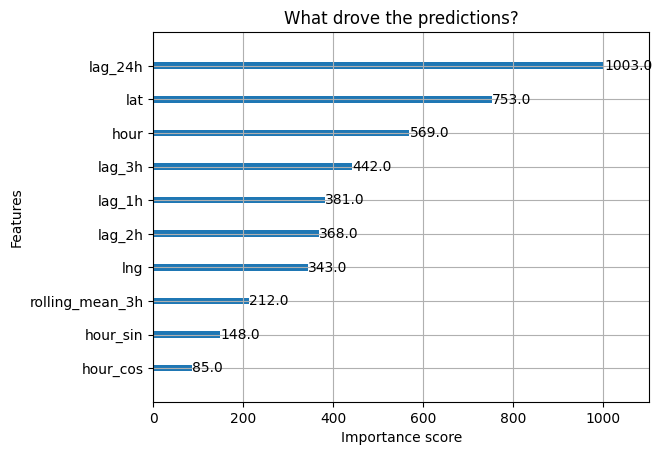

In [8]:
# 7. Feature Importance
print("\nPlotting Feature Importance...")
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, importance_type='weight', max_num_features=10, title='What drove the predictions?')
plt.show()

Evaluating on the test set...

--- 📊 Model Performance ---
RMSE (Root Mean Squared Error): 3.67 bikes
MAE (Mean Absolute Error): 0.96 bikes
R² Score: 0.9996

Interpretation: Your model explains 99.96% of the variance in bike demand.


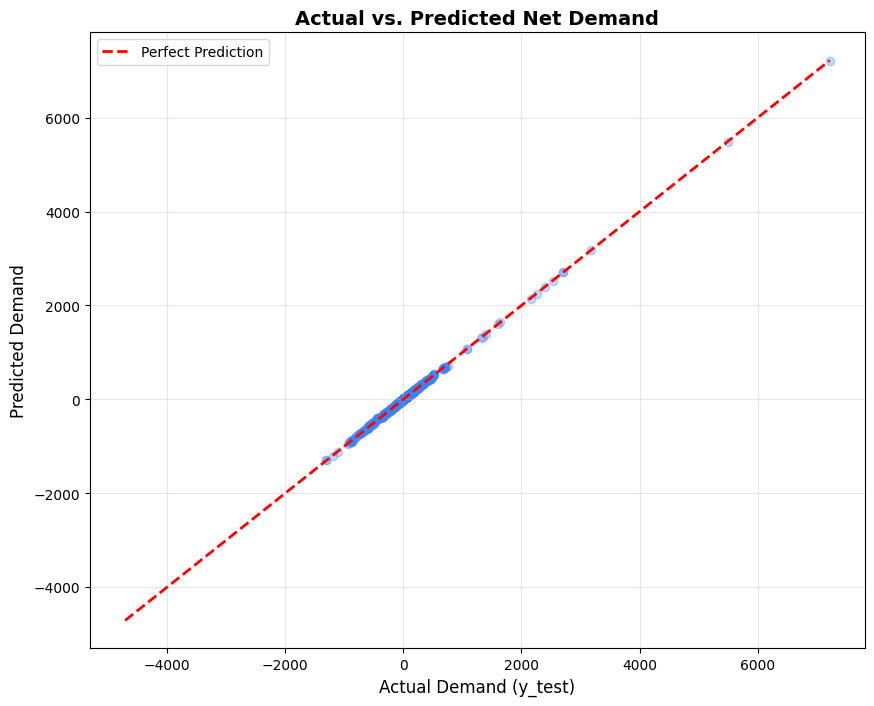


Plotting Feature Importance...


<Figure size 1000x600 with 0 Axes>

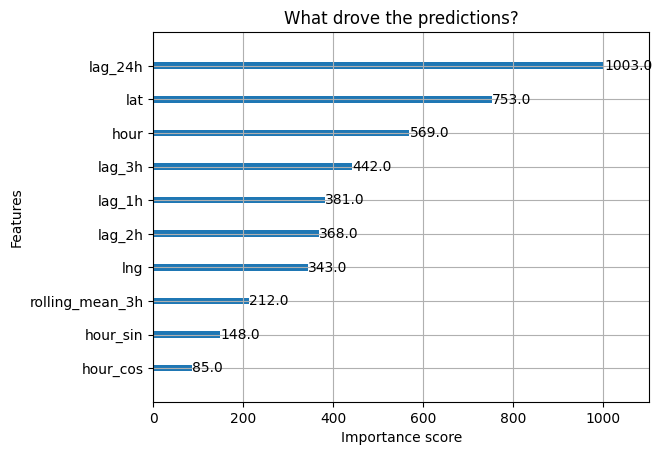

In [9]:
from sklearn.metrics import r2_score
import seaborn as sns

# 6. Evaluate the Model
# Important: Ensure final_model is loaded from the latest checkpoint
final_model = xgb.XGBRegressor()
final_model.load_model(checkpoint_path)

print("Evaluating on the test set...")
predictions = final_model.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- 📊 Model Performance ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} bikes")
print(f"MAE (Mean Absolute Error): {mae:.2f} bikes")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: Your model explains {r2*100:.2f}% of the variance in bike demand.")

# 7. Visual Metric: Actual vs. Predicted Scatter Plot
plt.figure(figsize=(10, 8))
# We use a sample if the test set is too large to keep the plot responsive
sample_size = min(5000, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

plt.scatter(y_test.iloc[sample_indices], predictions[sample_indices], alpha=0.3, color='#3b82f6')

# Add the "Perfect Prediction" line (y=x)
max_val = max(y_test.max(), predictions.max())
min_val = min(y_test.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Net Demand', fontsize=14, fontweight='bold')
plt.xlabel('Actual Demand (y_test)', fontsize=12)
plt.ylabel('Predicted Demand', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. Feature Importance
print("\nPlotting Feature Importance...")
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, importance_type='weight', max_num_features=10, title='What drove the predictions?')
plt.show()